Status: optimal
Custo Total Anual: 41925.69 $

Resumo do Mês Inicial (t=0):
Geração das Usinas (MVA):
  Usina 1: 0.0 MVA
  Usina 2: 0.0 MVA
  Usina 3: 180.0 MVA

Nível do Reservatório (hm³):
  Início: 400.0 hm³ -> Fim do Ano: 20.0 hm³

Fluxo nas Linhas de Transmissão (MVA) - Mês 0:
  Linha 1: 6.0 MVA
  Linha 2: -42.0 MVA
  Linha 3: -48.0 MVA

Ângulo das Tensões (rad) - Mês 0:
  Barra 1: 0.0000 rad
  Barra 2: -5.9999 rad
  Barra 3: 41.9922 rad


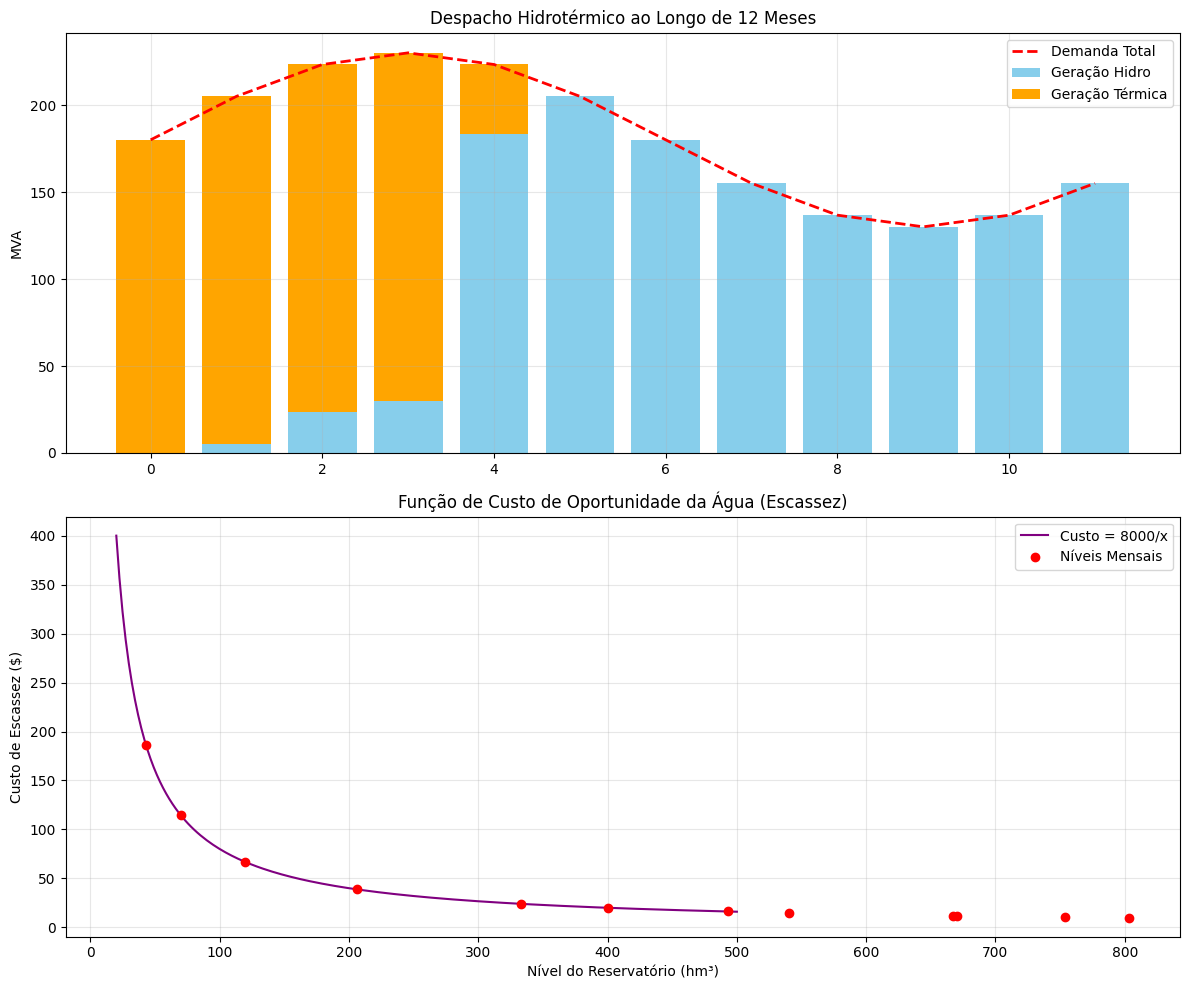

In [5]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Configurações Temporais ---
meses = 12
t = np.arange(meses)

# --- 2. Dados da Rede Elétrica ---
n_usinas = 3  # Usina 1 e 2 (Hidro), Usina 3 (Térmica)
n_linhas = 3
n_cargas = 3

# Matriz de incidência (Topologia: 1-2, 1-3, 2-3)
A = np.array([
    [1, -1, 0],
    [1, 0, -1],
    [0, 1, -1]
])

P_max = np.array([100, 150, 200]) # Capacidade das Usinas (MVA)
F_max = np.array([50, 70, 80])    # Capacidade das Linhas (MVA)
c_termica = 50                    # Custo da Usina 3 ($/MVAh)

# --- 3. Dados Hídricos e Demanda Sazonal ---
# Demanda variando no ano (Pico no inverno/verão)
D_total = 180 + 50 * np.sin(2 * np.pi * t / 12)
# Afluência (Chuvas): Ciclo sazonal de chuvas
afluencia = 80 + 60 * np.cos(2 * np.pi * t / 12)

x0 = 400          # Volume inicial (hm³)
K_scarcity = 8000 # Custo de oportunidade (Valor da Água)
eta = 1.0         # Eficiência hídrica

# --- 4. Variáveis de Otimização (Multi-período) ---
P = cp.Variable((meses, n_usinas))    # Geração por mês/usina
F = cp.Variable((meses, n_linhas))    # Fluxo por mês/linha
theta = cp.Variable((meses, n_cargas)) # Ângulo por mês/barra
x = cp.Variable(meses + 1)            # Nível do reservatório (hm³)

# --- 5. Função Objetivo ---
# Minimiza: Custo Térmico + Penalidade de Escassez (Inverso do Nível)
custo_operacional = cp.sum(c_termica * P[:, 2])
custo_escassez = K_scarcity * cp.sum(cp.inv_pos(x))
obj = cp.Minimize(custo_operacional + custo_escassez)

# --- 6. Restrições ---
constraints = [x[0] == x0] # Volume Inicial

for m in range(meses):
    # Distribuição da carga entre as barras
    D_barra = np.array([0.2, 0.3, 0.5]) * D_total[m]

    constraints += [
        # Balanço de Potência Global e por Barra (LKC)
        cp.sum(P[m, :]) == D_total[m],
        P[m, :] - D_barra == A.T @ F[m, :],

        # Limites de Geração e Transmissão
        P[m, :] <= P_max,
        P[m, :] >= 0,
        F[m, :] <= F_max,
        F[m, :] >= -F_max,

        # Leis de Kirchhoff (Fluxo DC)
        F[m, :] == A @ theta[m, :],
        theta[m, 0] == 0,

        # Dinâmica do Reservatório (Continuidade)
        # Usinas 1 e 2 são as hidrelétricas do sistema
        x[m+1] == x[m] + afluencia[m] - cp.sum(P[m, :2]) * eta,
        x[m+1] >= 20 # Nível mínimo de segurança
    ]

# --- 7. Solução do Problema ---
prob = cp.Problem(obj, constraints)
prob.solve()

# --- 8. Exibição dos Resultados ---
if prob.status == 'optimal':
    print(f"Status: {prob.status}")
    print(f"Custo Total Anual: {prob.value:.2f} $\n")

    print(f"Resumo do Mês Inicial (t=0):")
    print("Geração das Usinas (MVA):")
    for i in range(n_usinas):
        print(f"  Usina {i+1}: {P.value[0, i]:.1f} MVA")

    print("\nNível do Reservatório (hm³):")
    print(f"  Início: {x.value[0]:.1f} hm³ -> Fim do Ano: {x.value[-1]:.1f} hm³")

    print("\nFluxo nas Linhas de Transmissão (MVA) - Mês 0:")
    for i in range(n_linhas):
        print(f"  Linha {i+1}: {F.value[0, i]:.1f} MVA")

    print("\nÂngulo das Tensões (rad) - Mês 0:")
    for i in range(n_cargas):
        print(f"  Barra {i+1}: {theta.value[0, i]:.4f} rad")

    # --- 9. Gráficos de Operação e Custo ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Subplot 1: Despacho Hidrotérmico Mensal
    ax1.bar(t, P.value[:, 0] + P.value[:, 1], label='Geração Hidro', color='skyblue')
    ax1.bar(t, P.value[:, 2], bottom=P.value[:, 0] + P.value[:, 1], label='Geração Térmica', color='orange')
    ax1.plot(t, D_total, 'r--', label='Demanda Total', linewidth=2)
    ax1.set_title("Despacho Hidrotérmico ao Longo de 12 Meses")
    ax1.set_ylabel("MVA")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Subplot 2: Curva de Custo da Água (Não Linear)
    x_vals_plot = np.linspace(20, 500, 200)
    custo_vals_non_linear = K_scarcity / x_vals_plot
    ax2.plot(x_vals_plot, custo_vals_non_linear, color='purple', label=f'Custo = {K_scarcity}/x')

    # Marcar os pontos ótimos mensais sobre a curva de escassez
    ax2.scatter(x.value[:-1], K_scarcity/x.value[:-1], color='red', zorder=5, label='Níveis Mensais')

    ax2.set_xlabel('Nível do Reservatório (hm³)')
    ax2.set_ylabel('Custo de Escassez ($)')
    ax2.set_title('Função de Custo de Oportunidade da Água (Escassez)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"O problema não encontrou uma solução ótima. Status: {prob.status}")